# Exercício 1 — Construção da Árvore

In [2]:
Valores = [53, 30, 72, 14, 39, 61, 84, 9, 23, 34, 49, 79]


# Mostre o dicionário completo da árvore
# Informe qual é a raiz
# Explique por que cada valor foi para esquerda ou direita.



arvore = {}

def construir_arvore(valores):

    for valor in valores:

        if len(arvore) == 0:
            arvore[valor] = {
                "esquerda": None,
                "direita": None
            }
            raiz = valor

        else:
            atual = raiz

            while True:
                if valor < atual:
                    if arvore[atual]["esquerda"] is None:
                        arvore[atual]["esquerda"] = valor
                        arvore[valor] = {
                            "esquerda": None,
                            "direita": None
                        }
                        break
                    else:
                        atual = arvore[atual]["esquerda"]

                else:
                    if arvore[atual]["direita"] is None:

                        arvore[atual]["direita"] = valor

                        arvore[valor] = {
                            "esquerda": None,
                            "direita": None
                        }

                        break

                    else:
                        atual = arvore[atual]["direita"]

    return raiz

raiz = construir_arvore(Valores)
print("Árvore Completa:", arvore)
print("Raiz da Árvore:", raiz)

Árvore Completa: {53: {'esquerda': 30, 'direita': 72}, 30: {'esquerda': 14, 'direita': 39}, 72: {'esquerda': 61, 'direita': 84}, 14: {'esquerda': 9, 'direita': 23}, 39: {'esquerda': 34, 'direita': 49}, 61: {'esquerda': None, 'direita': None}, 84: {'esquerda': 79, 'direita': None}, 9: {'esquerda': None, 'direita': None}, 23: {'esquerda': None, 'direita': None}, 34: {'esquerda': None, 'direita': None}, 49: {'esquerda': None, 'direita': None}, 79: {'esquerda': None, 'direita': None}}
Raiz da Árvore: 53


# Exercício 2 — Inserção de Novos Valores

# Exercício 3 — Busca de Elementos

# Exercício 4 — Travessia Pré-Ordem

# Exercício 5 — Travessia Em Ordem

# Exercício 6 — Travessia Pós-Ordem

# Exercício 7 — Altura da Árvore

# Exercício 8 — Contagem de Nós

# Exercício 9 — Menor e Maior Valor

# Exercício 10 — Remoção de Nó Folha

# Exercício 11 — Remoção de Nó com Um Filho

# Exercício 12 — Remoção de Nó com Dois Filhos

# Exercício 13 — Busca de Profundidade

# Exercício 14 — Busca em Largura

# Exercício 15 — Verificação de Existência

# Exercício 16 — Soma dos Valores da Árvore

# Exercício 17 — Conversão para Lista Ordenada

# Exercício 18 — Verificação de Balanceamento

# Exercício 19 — Desenho da Árvore

# Exercício 20 — Desafio

Exercícios Teóricos
Exercício 21
Explique a diferença entre:
árvore binária
árvore binária de busca
Exercício 22
Explique:
O que é um nó raiz.
O que é um nó folha.
O que é altura.
O que é profundidade.
O que é subárvore.
Exercício 23
Qual é a complexidade média da busca em uma ABB?
Explique:
Melhor caso
Caso médio
Pior caso
Exercício 24
Explique por que árvores degeneradas podem se tornar semelhantes a listas encadeadas.
Dê exemplos.
Desafio Extra
Pesquise e explique:
Árvores AVL
Árvores Rubro-Negras
Diferença entre ABB comum e AVL
Por que árvores balanceadas são importantes

# Árvore Trie

fazer um 

In [1]:
# Árvore Trie

avore_trie = {}

def adicionar_palavra(arvore, palavra):
    atual = arvore

    for letra in palavra:
        if letra not in atual:
            atual[letra] = {}
        atual = atual[letra]

    atual["*"] = True  # Marca o fim da palavra

def pesquisar_palavra(arvore, palavra):
    atual = arvore

    for letra in palavra:
        if letra not in atual:
            return False
        atual = atual[letra]

    return "*" in atual  # Verifica se é o fim da palavra



In [8]:
# Exemplo de uso
adicionar_palavra(avore_trie, "feijão")
print("Árvore Trie:", avore_trie)
print("Pesquisar 'casa':", pesquisar_palavra(avore_trie, "casa"))
print("Pesquisar 'casinha':", pesquisar_palavra(avore_trie, "casinha"))
print("Pesquisar 'ontem':", pesquisar_palavra(avore_trie, "ontem"))

Árvore Trie: {'f': {'a': {'z': {'e': {'r': {'*': True}}}}, 'e': {'i': {'j': {'ã': {'o': {'*': True}}}}}}, 'A': {'r': {'u': {'a': {'n': {'e': {'*': True}}}}, 'r': {'o': {'z': {'*': True}}}}}}
Pesquisar 'casa': False
Pesquisar 'casinha': False
Pesquisar 'ontem': False


In [2]:
import matplotlib.pyplot as plt
import networkx as nx

def desenhar_trie_perfeita(trie_dict):
    G = nx.DiGraph()
    G.add_node("root", label="Raiz", color="lightblue")

    # 1. Constrói o Grafo iterando pelos dicionários
    def construir_grafo(sub_trie, id_pai):
        for chave, valor in sub_trie.items():
            if chave == '*':
                G.nodes[id_pai]['color'] = 'lightgreen'
                continue
            
            id_filho = f"{id_pai}_{chave}_{id(valor)}"  # ID único para evitar colisões
            G.add_node(id_filho, label=chave, color="gainsboro")
            G.add_edge(id_pai, id_filho)
            
            if isinstance(valor, dict):
                construir_grafo(valor, id_filho)

    construir_grafo(trie_dict, "root")

    # 2. Algoritmo para posicionar os nós perfeitamente em formato de árvore (Cima para Baixo)
    def _hierarchy_pos(graph, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None):
        if pos is None:
            pos = {root: (xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
            
        children = list(graph.neighbors(root))
        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(graph, child, width=dx, vert_gap=vert_gap, 
                                     vert_loc=vert_loc-vert_gap, xcenter=nextx, pos=pos)
        return pos

    # Calcula as posições perfeitas dos nós
    pos = _hierarchy_pos(G, "root")

    # 3. Renderização do Gráfico com Matplotlib
    labels = nx.get_node_attributes(G, 'label')
    node_colors = [G.nodes[n].get('color', 'gainsboro') for n in G.nodes()]

    # Aumenta o tamanho da figura dinamicamente com base no tamanho da árvore
    largura_figura = max(10, len(G.nodes) // 3)
    plt.figure(figsize=(largura_figura, 8))
    
    # Desenha os nós, linhas e letras
    nx.draw_networkx_nodes(G, pos, node_size=900, node_color=node_colors, edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="gray", width=1.2)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight="bold")

    plt.title("Visualização Hierárquica da Árvore Trie", fontsize=14, fontweight="bold", pad=20)
    plt.axis("off")
    plt.show()

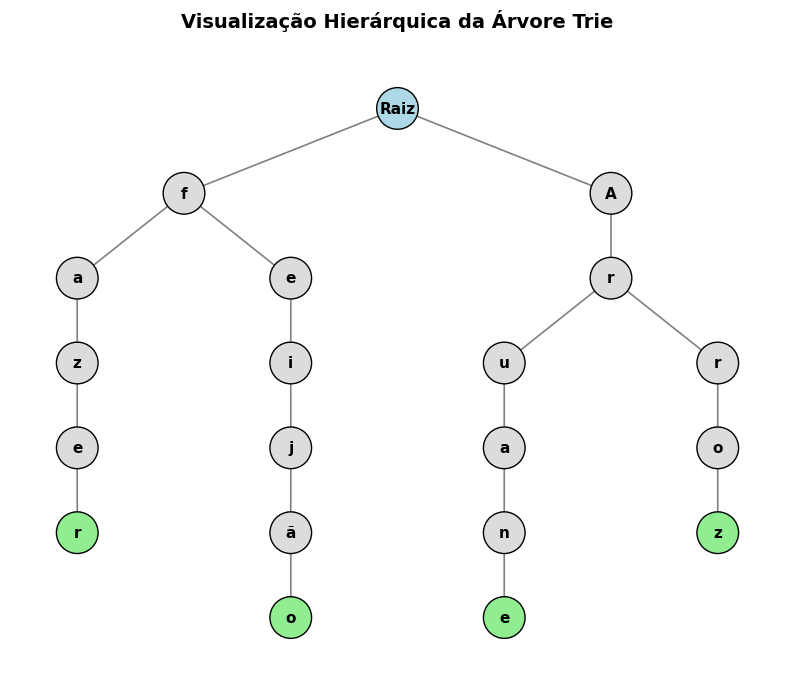

In [9]:
desenhar_trie_perfeita(avore_trie)

In [ ]:
def separa_palavras_frase(frase):
    palavras = frase.split()
    return palavras

def adicionar_palavras_trie(avore_trie, palavras):
    for palavra in palavras:
        adicionar_palavra(avore_trie, palavra)
    return True

def sugestoes_palavras_trie(avore_trie, prefixo):
    atual = avore_trie
    for letra in prefixo:
        if letra not in atual:
            return []
        atual = atual[letra]

    sugestoes = []

    def coletar_palavras(sub_trie, caminho):
        for chave, valor in sub_trie.items():
            if chave == '*':
                sugestoes.append(caminho)
            elif isinstance(valor, dict):
                coletar_palavras(valor, caminho + chave)

    coletar_palavras(atual, prefixo)
    return sugestoes


In [ ]:
frase = input("Digite uma frase: ")
palavras = separa_palavras_frase(frase)
adicionar_palavras_trie(avore_trie, palavras)

In [44]:
prefixo = input("Digite as primeiras letras: ")
sugestoes = sugestoes_palavras_trie(avore_trie, prefixo)
print("Sugestões de palavras:", sugestoes)

Digite as primeiras letras:  li


Sugestões de palavras: ['lindo']
